<a href="https://colab.research.google.com/github/mohitgoyal1409/machine_learning/blob/main/37_polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , SGDRegressor
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error , r2_score

In [39]:
X = 6*np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9*X + 2 + np.random.randn(200,1)

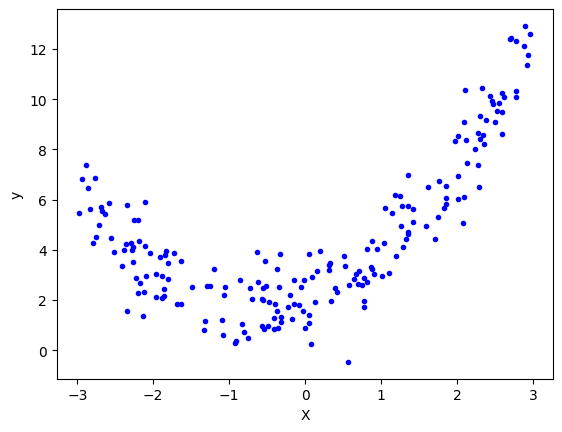

In [40]:
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [42]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [43]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.10307887268372617

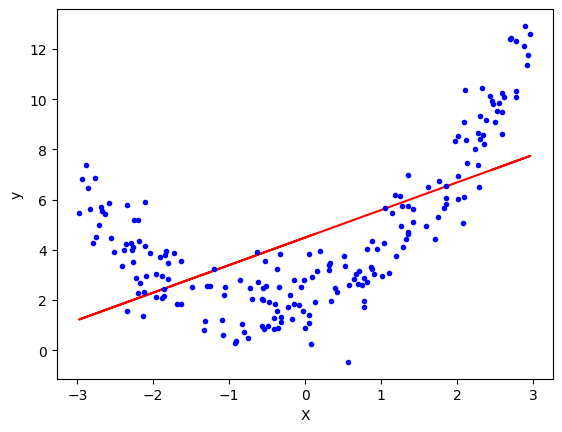

In [44]:
plt.plot(X_train, lr.predict(X_train), color='r')
plt.plot(X, y,"b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [45]:
poly = PolynomialFeatures(degree=2)
X_train_trans = poly.fit_transform(X_train)

In [46]:
X_test_trans = poly.transform(X_test)

In [47]:
print(X_train[0])
print(X_train_trans[0])

[0.13058891]
[1.         0.13058891 0.01705346]


In [48]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [49]:
y_pred = lr.predict(X_test_trans)
r2_score(y_test,y_pred)

0.8311947740414447

In [50]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.99304534 0.83204755]]
[1.95850025]


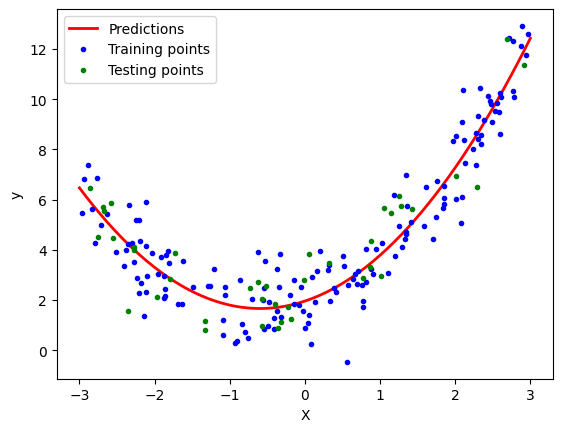

In [51]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [52]:
# 3d polynomial regression
x = 7*np.random.rand(100,1) - 2.8
y = 7*np.random.rand(100,1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100,1)

In [53]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [54]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(),x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final=np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)

In [55]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [56]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [57]:
poly = PolynomialFeatures(degree=2)
X_multi_trans = poly.fit_transform(X_multi)

In [58]:
print("input",poly.n_features_in_)
print("input",poly.n_output_features_)
print("output",poly.powers_)

input 2
input 6
output [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]


In [59]:
lr =  LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [60]:
X_test_multi = poly.transform(final)

In [61]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [62]:
fig = px.scatter_3d(x=x.ravel(),y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()